# Actividad: Carga, Limpieza y Visualización de Datos

En este notebook se realizará:
- Carga de datos con **Pandas** y **NumPy**
- Limpieza de valores nulos
- Creación de una nueva variable
- Visualización de datos con **Matplotlib**

Carga de codigo


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# URL del dataset
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"

# Cargar datos
df = pd.read_csv(url)

# Mostrar primeras filas
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


Tipos de datos

In [3]:
df.dtypes

,0
mpg,float64
cylinders,int64
displacement,float64
horsepower,float64
weight,int64
acceleration,float64
model_year,int64
origin,object
name,object


Valores nulos en horsepower

In [4]:
df['horsepower'].isnull().sum()

np.int64(6)

Limpieza y media

In [5]:
# Convertir a numérico (por si hay strings)
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')

# Calcular mediana
mediana = np.median(df['horsepower'].dropna())

# Reemplazar nulos
df['horsepower'] = df['horsepower'].fillna(mediana)

# Verificar
df['horsepower'].isnull().sum()

np.int64(0)

Nueva Columna

In [6]:
df['relacion_peso_potencia'] = df['weight'] / df['horsepower']

df[['weight', 'horsepower', 'relacion_peso_potencia']].head()

,weight,horsepower,relacion_peso_potencia
0,3504,130.0,26.953846
1,3693,165.0,22.381818
2,3436,150.0,22.906667
3,3433,150.0,22.886667
4,3449,140.0,24.635714


Graficas

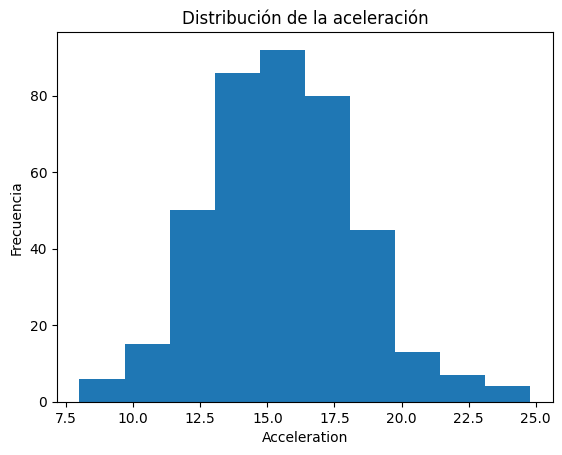

In [7]:
plt.figure()
plt.hist(df['acceleration'])
plt.title('Distribución de la aceleración')
plt.xlabel('Acceleration')
plt.ylabel('Frecuencia')
plt.show()

Scatter

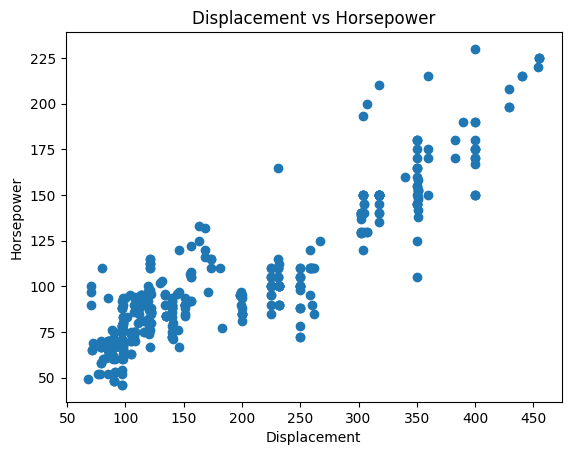

In [8]:
plt.figure()
plt.scatter(df['displacement'], df['horsepower'])
plt.title('Displacement vs Horsepower')
plt.xlabel('Displacement')
plt.ylabel('Horsepower')
plt.show()

Promedio por pais de origen

In [9]:
promedio = df.groupby('origin')['mpg'].mean()
promedio

,mpg
origin,
europe,27.891429
japan,30.450633
usa,20.083534


Grafica de barras

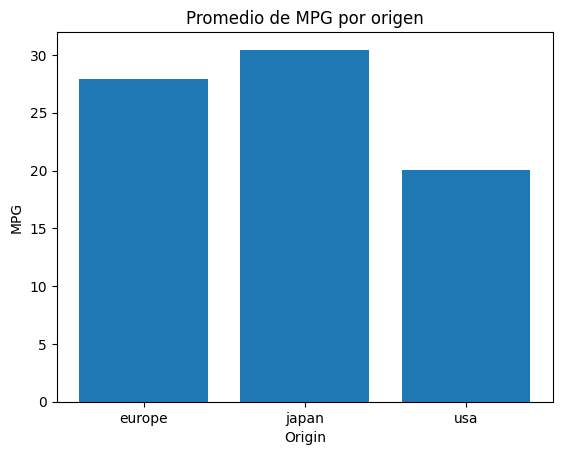

In [10]:
plt.figure()
plt.bar(promedio.index.astype(str), promedio.values)
plt.title('Promedio de MPG por origen')
plt.xlabel('Origin')
plt.ylabel('MPG')
plt.show()

(array([ 6., 15., 50., 86., 92., 80., 45., 13.,  7.,  4.]),
 array([ 8.  ,  9.68, 11.36, 13.04, 14.72, 16.4 , 18.08, 19.76, 21.44,
        23.12, 24.8 ]),
 <BarContainer object of 10 artists>)

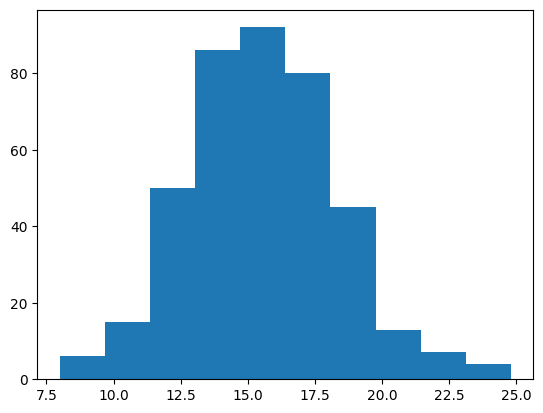

In [11]:
plt.hist(df['acceleration'])